In [4]:
import keras
from keras.models import Sequential
from keras.layers import Dense
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

/home/thierry/PycharmProjects/Outils-IA/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1773418024.242951  407233 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 4)              │            16 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │            10 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29 (116.00 B)

 Trainable params: 29 (116.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 708ms/step - accuracy: 0.5000 - loss: 0.7079
Epoch 2/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.5000 - loss: 0.7053
Epoch 3/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.5000 - loss: 0.7026
Epoch 4/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.5000 - loss: 0.7000
Epoch 5/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.5000 - loss: 0.6974
Epoch 6/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.5000 - loss: 0.6948
Epoch 7/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.5000 - loss: 0.6922
Epoch 8/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.5000 - loss: 0.6896
Epoch 9/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.5000 - loss: 0.6871
Epoch 10/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.5000 - loss: 0.6845
Epoch 11/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.5000 - loss: 0.6820
Epoch 12/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy

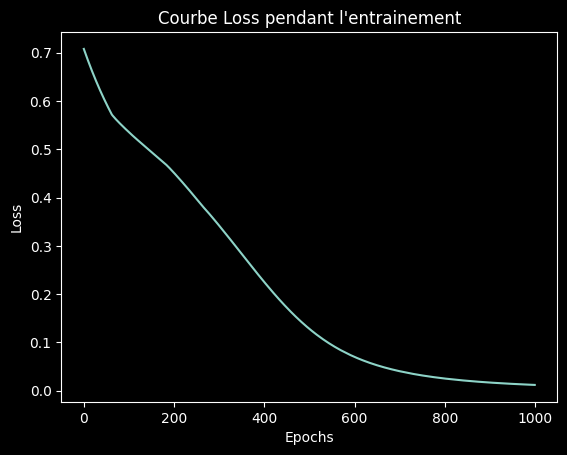

In [2]:
# DOnnées d'exmple : 4 exemples avec 3 entrées chacun (Fonction logique AND)

X = np.array([[0,0,0],
             [0,0,1],
             [0,1,1],
             [1,1,1]])

y = np.array([0,0,0,1])


# Normalisation des données
scaler = StandardScaler()
X_normalized = scaler.fit_transform(X)


#creation du modèle séquentiel
model = Sequential()


# Couche d'entrée (3 entrées) + 1ère couche cachée avec 4 neuronnes + ReLU
model.add(Dense(4, input_dim=3, activation='relu'))

# 2eme Couche cahcée avec 2 neuronnes + ReLU
model.add(Dense(2, activation='relu'))

# Couche de sortie (1 neuronne) + activation sigmoïde pour une sortie binaire
model.add(Dense(1, activation='sigmoid'))

# compilation du modèle
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

#Résumé du modele
model.summary()

#Entrainement du modele avec un nombre d'époques plus élevé et stockage de l'historique
history = model.fit(X_normalized, y, epochs=1000, verbose=1)


# Prédiction sur les données d'entrée
predictions = model.predict(X_normalized)

# Affichage des prédictions continues (probabilités)
print(f"Predictions (probabilités): {predictions}")

# Convertir les prédictions continues en valeurs binaires (0 ou 1) avec un seuil de 0,5
predictions_binary = (predictions > 0.5).astype(int)

# Affichage des prédictions binaires
print(f"Prédictions binaies: {predictions_binary}")

# Tracer la courbe de loss pendant l'entrainement
plt.plot(history.history['loss'])
plt.title('Courbe Loss pendant l\'entrainement')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()



